# 02 — Graph Construction

**Goal:** Build G = (V, E) from the dataset entity structure and analyse topology.

**Checkpoint:** Reproducible graph with correct node types, edge types, centrality metrics, and saved visualisations.

**Sections:**
1. Setup & graph construction
2. Graph summary (node / edge counts by type)
3. Full graph — layered layout, colour by node type
4. Centrality analysis — which nodes are most critical?
5. Degree distribution
6. Cross-plant dependency subgraph

In [ ]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

np.random.seed(42)

# Make src importable from the notebook
ROOT = Path(os.getcwd()).parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.loader import load_csv
from src.data.preprocess import preprocess
from src.data.entity_mapping import build_entity_mappings
from src.graph.topology import infer_topology
from src.graph.builder import build_graph, print_graph_summary
from src.graph.metrics import (
    degree_centrality,
    betweenness_centrality,
    critical_nodes,
    vulnerable_edges,
    network_stats,
    vulnerability_analysis,
)

# ── output directory ───────────────────────────────────────────────────────
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── light theme constants ──────────────────────────────────────────────────
BG_COLOR   = "white"
TEXT_COLOR = "#333333"
GRID_COLOR = "#EEEEEE"

# Layer colour palette (CODING_PATTERNS.md)
LAYER_COLORS = {
    "supplier":     "#3a86ff",   # blue
    "logistics":    "#9b5de5",   # purple
    "plant":        "#06d6a0",   # green
    "machine":      "#ffbe0b",   # amber
    "distribution": "#ef233c",   # red
}
EDGE_COLORS = {
    "material_flow":           "#3a86ff",
    "operational":             "#06d6a0",
    "process_chain":           "#ffbe0b",
    "shared_part_dependency":  "#ef233c",
}

# Vertical positions per layer (supplier on top, distribution at bottom)
LAYER_Y = {
    "supplier":     4.0,
    "logistics":    3.0,
    "plant":        2.0,
    "machine":      1.0,
    "distribution": 0.0,
}


def apply_dark_theme(fig: plt.Figure, axes) -> None:
    """Apply the project light theme to a figure and all its axes."""
    fig.patch.set_facecolor(BG_COLOR)
    ax_list = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for ax in ax_list:
        ax.set_facecolor(BG_COLOR)
        ax.tick_params(colors=TEXT_COLOR)
        ax.xaxis.label.set_color(TEXT_COLOR)
        ax.yaxis.label.set_color(TEXT_COLOR)
        ax.title.set_color(TEXT_COLOR)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_COLOR)
        ax.grid(True, color=GRID_COLOR, linewidth=0.5)


print("Setup complete.")

---
## 1. Load Data & Build Graph

In [ ]:
# ── adjust filename to match your downloaded CSV ───────────────────────────
CSV_FILENAME = "updated_data.csv"

df_raw = load_csv(CSV_FILENAME)
print(f"Raw dataset : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

In [ ]:
df_clean, scalers = preprocess(df_raw, output_filename="updated_data_processed.csv")
print(f"Processed   : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

In [23]:
em = build_entity_mappings(df_raw)   # use raw df so keys stay human-readable strings

print(f"Plants      : {len(em.plant_codes):,}")
print(f"Machines    : {len(em.asset_tags):,}")
print(f"Part nos    : {len(em.part_nos):,}")
print(f"Part families: {len(em.part_families):,}")
print(f"Cross-plant shared parts: {len(em.cross_plant_parts):,}")

Plants      : 3
Machines    : 10
Part nos    : 20
Part families: 9
Cross-plant shared parts: 20


In [24]:
nodes, edges = infer_topology(em)
G = build_graph(nodes, edges, df_clean)
print(f"Graph  : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

[builder] Graph built — 26 nodes, 102 edges.
Graph  : 26 nodes, 102 edges


---
## 2. Graph Summary

In [25]:
print_graph_summary(G)


  DTNET GRAPH SUMMARY
  Total nodes : 26
    supplier            :     9  avg health = 0.930
    logistics           :     2  avg health = 0.935
    plant               :     3  avg health = 0.938
    machine             :    10  avg health = 0.700
    distribution        :     2  avg health = 0.892

  Total edges : 102
    material_flow                 :     19
    operational                   :     10
    process_chain                 :      7
    shared_part_dependency        :     66

  Connectivity
    Is weakly connected : True
    Is DAG              : False
    Avg out-degree      : 3.92



In [26]:
# ── network-level statistics ───────────────────────────────────────────────
stats = network_stats(G)

print("Network statistics")
print(f"  Density                        : {stats.density:.6f}")
print(f"  Avg path length (largest WCC)  : {stats.avg_path_length}")
print(f"  Avg clustering coefficient     : {stats.avg_clustering:.4f}")
print(f"  Weakly connected components    : {stats.num_weakly_connected_components}")
print(f"  Is DAG                         : {stats.is_dag}")

Network statistics
  Density                        : 0.156923
  Avg path length (largest WCC)  : 2.2984615384615386
  Avg clustering coefficient     : 0.2902
  Weakly connected components    : 1
  Is DAG                         : False


---
## 3. Full Graph — Layered Layout

In [27]:
def layered_positions(G: nx.DiGraph) -> dict:
    """Assign (x, y) positions with y fixed per layer and x spread evenly.

    Supplier nodes sit at the top (y=4), distribution at the bottom (y=0).
    Within each layer, nodes are sorted by ID and spread uniformly across
    x ∈ [-1, 1] to avoid overlap.
    """
    layers: dict = {l: [] for l in LAYER_Y}
    for node_id, data in G.nodes(data=True):
        layer = data.get("layer", "machine")
        if layer in layers:
            layers[layer].append(node_id)

    pos = {}
    for layer, node_ids in layers.items():
        node_ids = sorted(node_ids)
        n = len(node_ids)
        y = LAYER_Y[layer]
        for i, node_id in enumerate(node_ids):
            x = (i / max(n - 1, 1)) * 2.0 - 1.0 if n > 1 else 0.0
            pos[node_id] = (x, y)
    return pos


pos = layered_positions(G)
print(f"Positions computed for {len(pos)} nodes.")

Positions computed for 26 nodes.


Saved → c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\dtnet_graph.png


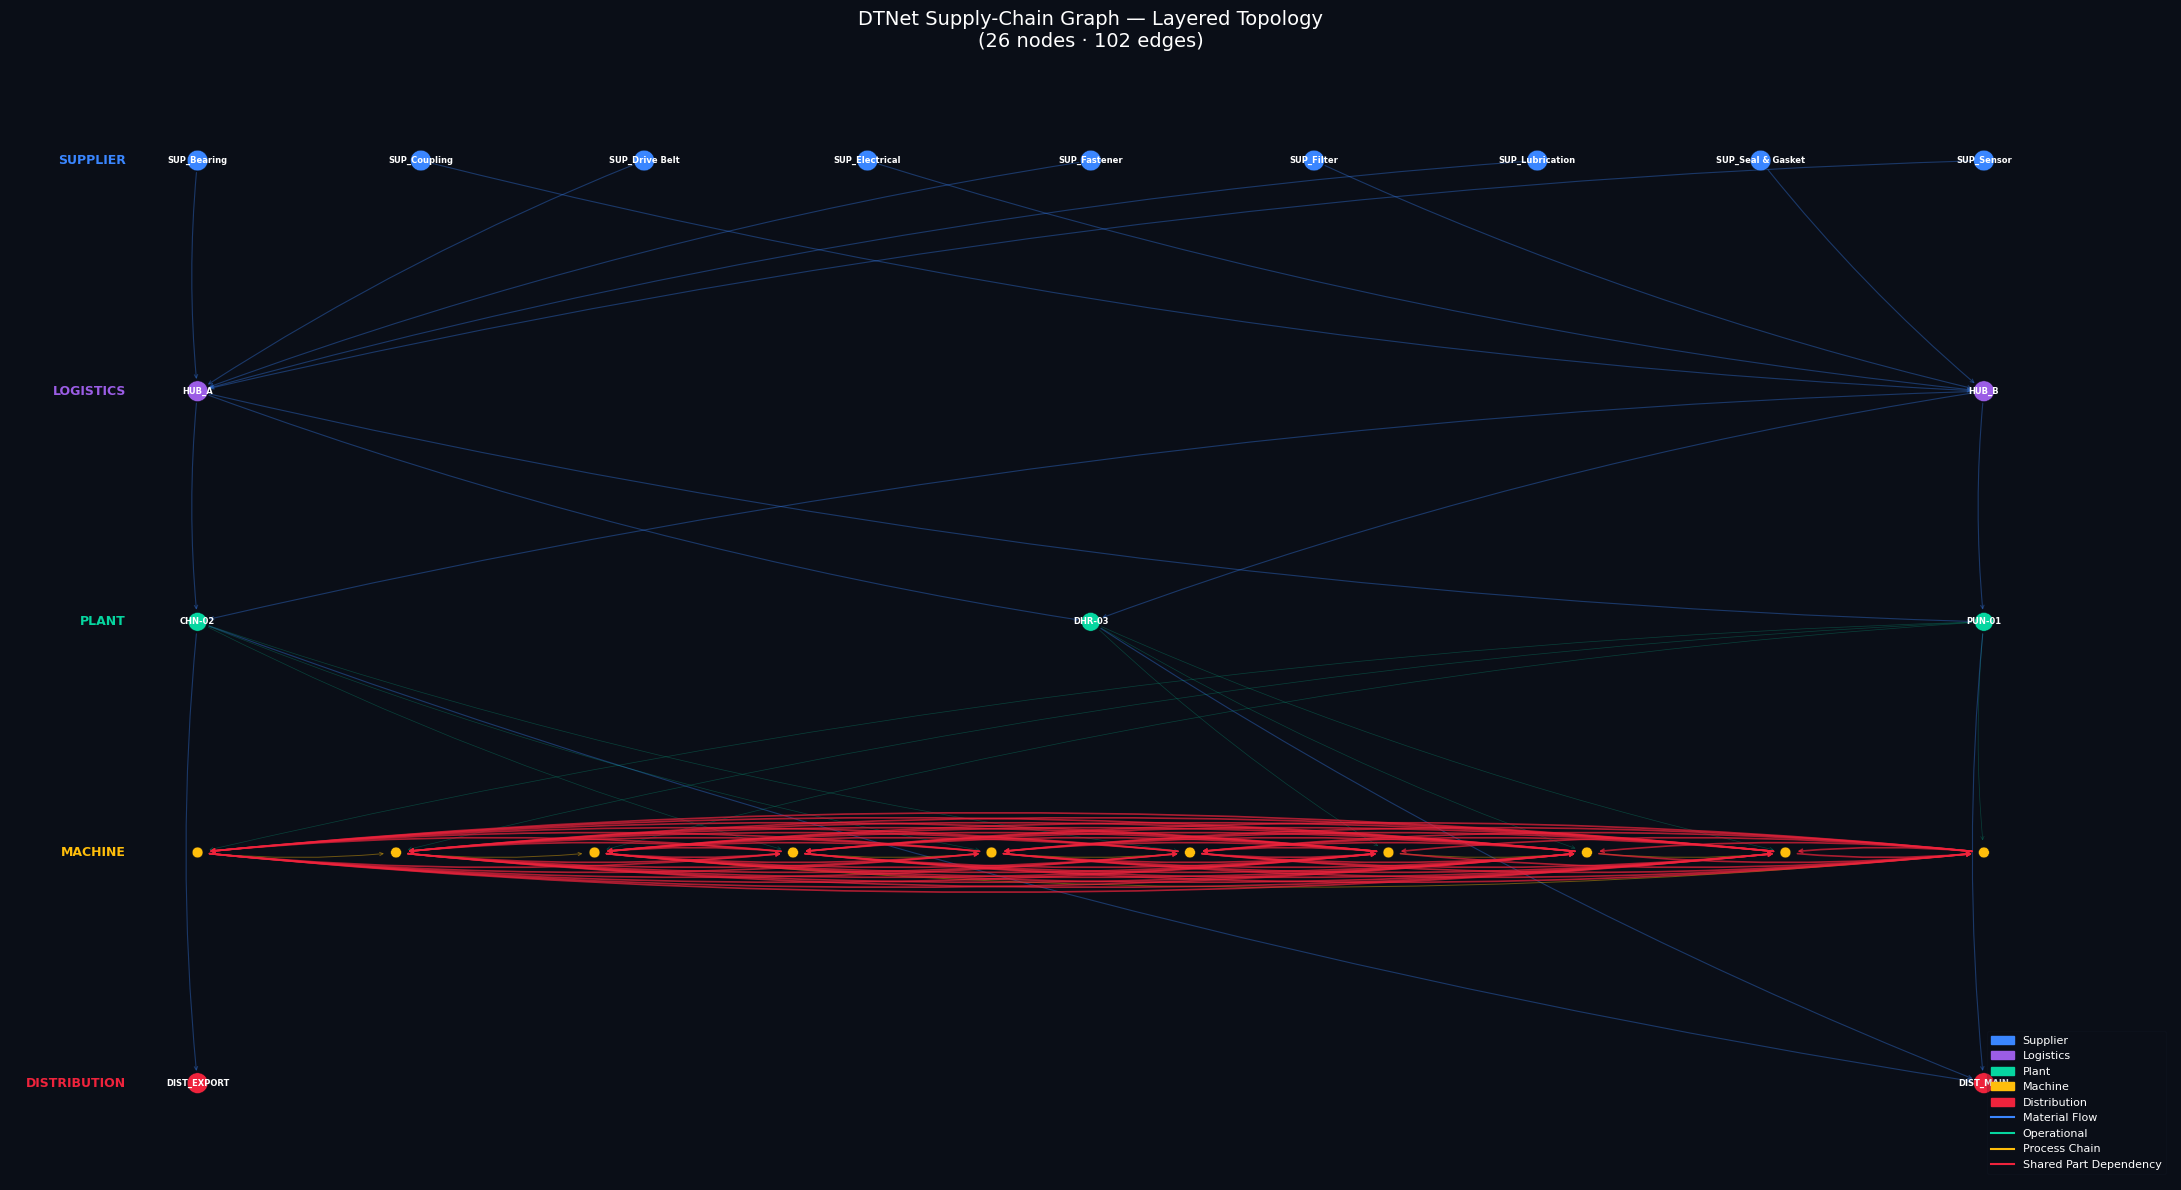

In [28]:
# ── node appearance ────────────────────────────────────────────────────────
node_colors  = [LAYER_COLORS.get(G.nodes[n].get("layer", ""), "white") for n in G.nodes()]
node_sizes   = [
    60  if G.nodes[n].get("layer") == "machine" else
    180 if G.nodes[n].get("layer") == "plant"   else
    220
    for n in G.nodes()
]

# ── edge appearance — group by type ───────────────────────────────────────
edge_groups: dict = {et: [] for et in EDGE_COLORS}
for u, v, data in G.edges(data=True):
    et = data.get("edge_type", "material_flow")
    if et in edge_groups:
        edge_groups[et].append((u, v))

EDGE_ALPHA = {"material_flow": 0.35, "operational": 0.25,
              "process_chain": 0.40, "shared_part_dependency": 0.70}
EDGE_WIDTH = {"material_flow": 0.8,  "operational": 0.5,
              "process_chain": 0.7,  "shared_part_dependency": 1.2}

# ── figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 12))
apply_dark_theme(fig, ax)
ax.grid(False)
ax.set_axis_off()

# Draw edges by type
for et, elist in edge_groups.items():
    if elist:
        nx.draw_networkx_edges(
            G, pos, edgelist=elist, ax=ax,
            edge_color=EDGE_COLORS[et],
            alpha=EDGE_ALPHA[et],
            width=EDGE_WIDTH[et],
            arrows=True,
            arrowsize=6,
            arrowstyle="->",
            connectionstyle="arc3,rad=0.05",
            min_source_margin=4,
            min_target_margin=4,
        )

# Draw nodes
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    linewidths=0.3,
    edgecolors=BG_COLOR,
)

# Labels only for non-machine nodes (too many machines to label)
non_machine_labels = {
    n: n for n in G.nodes() if G.nodes[n].get("layer") != "machine"
}
nx.draw_networkx_labels(
    G, pos, labels=non_machine_labels, ax=ax,
    font_size=6, font_color=TEXT_COLOR, font_weight="bold",
)

# ── layer annotations on the left ─────────────────────────────────────────
for layer, y in LAYER_Y.items():
    ax.text(
        -1.08, y, layer.upper(),
        color=LAYER_COLORS[layer], fontsize=9, fontweight="bold",
        va="center", ha="right",
    )

# ── legend ─────────────────────────────────────────────────────────────────
node_patches = [
    mpatches.Patch(color=c, label=l.capitalize())
    for l, c in LAYER_COLORS.items()
]
edge_lines = [
    matplotlib.lines.Line2D([0], [0], color=c, linewidth=1.5, label=l.replace("_", " ").title())
    for l, c in EDGE_COLORS.items()
]
legend = ax.legend(
    handles=node_patches + edge_lines,
    loc="lower right", framealpha=0.15,
    labelcolor=TEXT_COLOR, fontsize=8,
    facecolor=BG_COLOR, edgecolor=GRID_COLOR,
)

ax.set_title(
    "DTNet Supply-Chain Graph — Layered Topology\n"
    f"({G.number_of_nodes()} nodes · {G.number_of_edges()} edges)",
    color=TEXT_COLOR, fontsize=14, pad=12,
)

plt.tight_layout()
out_path = RESULTS_DIR / "dtnet_graph.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
print(f"Saved → {out_path}")
plt.show()

---
## 4. Centrality Analysis

In [29]:
# ── degree centrality ──────────────────────────────────────────────────────
dc = degree_centrality(G)

# Top 10 by in-degree
top_in = sorted(dc.in_degree.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by IN-DEGREE centrality (many suppliers / inputs):")
for rank, (node_id, score) in enumerate(top_in, 1):
    layer = G.nodes[node_id].get("layer", "?")
    print(f"  {rank:>2}. {node_id:<30} [{layer:<12}]  in-degree = {score:.4f}")

Top 10 nodes by IN-DEGREE centrality (many suppliers / inputs):
   1. AST-3008                       [machine     ]  in-degree = 0.3600
   2. AST-3019                       [machine     ]  in-degree = 0.3600
   3. AST-4061                       [machine     ]  in-degree = 0.3600
   4. AST-5003                       [machine     ]  in-degree = 0.3600
   5. AST-1042                       [machine     ]  in-degree = 0.3200
   6. AST-2017                       [machine     ]  in-degree = 0.3200
   7. AST-2031                       [machine     ]  in-degree = 0.3200
   8. AST-4055                       [machine     ]  in-degree = 0.3200
   9. AST-5007                       [machine     ]  in-degree = 0.3200
  10. AST-1041                       [machine     ]  in-degree = 0.2800


In [30]:
# Top 10 by out-degree
top_out = sorted(dc.out_degree.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by OUT-DEGREE centrality (many dependents):")
for rank, (node_id, score) in enumerate(top_out, 1):
    layer = G.nodes[node_id].get("layer", "?")
    print(f"  {rank:>2}. {node_id:<30} [{layer:<12}]  out-degree = {score:.4f}")

Top 10 nodes by OUT-DEGREE centrality (many dependents):
   1. AST-2031                       [machine     ]  out-degree = 0.3200
   2. AST-3008                       [machine     ]  out-degree = 0.3200
   3. AST-4055                       [machine     ]  out-degree = 0.3200
   4. AST-4061                       [machine     ]  out-degree = 0.3200
   5. AST-1041                       [machine     ]  out-degree = 0.2800
   6. AST-1042                       [machine     ]  out-degree = 0.2800
   7. AST-2017                       [machine     ]  out-degree = 0.2800
   8. AST-3019                       [machine     ]  out-degree = 0.2800
   9. AST-5003                       [machine     ]  out-degree = 0.2800
  10. AST-5007                       [machine     ]  out-degree = 0.2400


In [31]:
# ── betweenness centrality ─────────────────────────────────────────────────
print("Computing betweenness centrality (may take a moment for large graphs)...")
bc = betweenness_centrality(G)

top_bc = sorted(bc.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 nodes by BETWEENNESS centrality (bottlenecks on critical paths):")
for rank, (node_id, score) in enumerate(top_bc, 1):
    layer = G.nodes[node_id].get("layer", "?")
    print(f"  {rank:>2}. {node_id:<30} [{layer:<12}]  betweenness = {score:.6f}")

Computing betweenness centrality (may take a moment for large graphs)...

Top 10 nodes by BETWEENNESS centrality (bottlenecks on critical paths):
   1. HUB_A                          [logistics   ]  betweenness = 0.125000
   2. HUB_B                          [logistics   ]  betweenness = 0.100000
   3. CHN-02                         [plant       ]  betweenness = 0.079444
   4. PUN-01                         [plant       ]  betweenness = 0.079444
   5. DHR-03                         [plant       ]  betweenness = 0.061111
   6. AST-3008                       [machine     ]  betweenness = 0.008214
   7. AST-4061                       [machine     ]  betweenness = 0.008214
   8. AST-2031                       [machine     ]  betweenness = 0.006548
   9. AST-3019                       [machine     ]  betweenness = 0.006548
  10. AST-4055                       [machine     ]  betweenness = 0.006548


In [32]:
# ── most vulnerable edges ──────────────────────────────────────────────────
top_edges = vulnerable_edges(G, top_n=10)
print("Top 10 most VULNERABLE EDGES (highest criticality_weight):")
for rank, (src, tgt, cw) in enumerate(top_edges, 1):
    et = G.edges[src, tgt].get("edge_type", "?")
    print(f"  {rank:>2}. {src:<25} → {tgt:<25} [{et:<25}]  cw = {cw:.3f}")

Top 10 most VULNERABLE EDGES (highest criticality_weight):
   1. CHN-02                    → AST-2031                  [operational              ]  cw = 0.900
   2. CHN-02                    → AST-3008                  [operational              ]  cw = 0.900
   3. CHN-02                    → AST-3019                  [operational              ]  cw = 0.900
   4. DHR-03                    → AST-4055                  [operational              ]  cw = 0.900
   5. DHR-03                    → AST-4061                  [operational              ]  cw = 0.900
   6. DHR-03                    → AST-5003                  [operational              ]  cw = 0.900
   7. PUN-01                    → AST-1041                  [operational              ]  cw = 0.900
   8. PUN-01                    → AST-1042                  [operational              ]  cw = 0.900
   9. PUN-01                    → AST-2017                  [operational              ]  cw = 0.900
  10. PUN-01                    → AST-500

In [33]:
# ── composite vulnerability analysis ──────────────────────────────────────
vuln = vulnerability_analysis(G, top_n=5)
print("=" * 70)
print("TOP 5 MOST CRITICAL NODES (composite vulnerability score)")
print("=" * 70)
for rank, v in enumerate(vuln, 1):
    hs = f"{v.health_score:.3f}" if v.health_score is not None else "n/a"
    print(f"\n#{rank}  {v.node_id}  [layer: {v.layer}]")
    print(f"    Vulnerability score : {v.vulnerability_score:.4f}")
    print(f"    Betweenness         : {v.betweenness:.6f}")
    print(f"    In-degree           : {v.in_degree_centrality:.4f}")
    print(f"    Out-degree          : {v.out_degree_centrality:.4f}")
    print(f"    Dependents          : {v.num_dependents}")
    print(f"    Health score        : {hs}")
    print(f"    Why critical        : {v.reason}")
print("=" * 70)

TOP 5 MOST CRITICAL NODES (composite vulnerability score)

#1  AST-3008  [layer: machine]
    Vulnerability score : 0.2067
    Betweenness         : 0.008214
    In-degree           : 0.3600
    Out-degree          : 0.3200
    Dependents          : 9
    Health score        : 0.692
    Why critical        : AST-3008 [machine]: high fan-out (0.320) — feeds many downstream nodes; 9 dependent nodes.

#2  AST-4061  [layer: machine]
    Vulnerability score : 0.2054
    Betweenness         : 0.008214
    In-degree           : 0.3600
    Out-degree          : 0.3200
    Dependents          : 9
    Health score        : 0.717
    Why critical        : AST-4061 [machine]: high fan-out (0.320) — feeds many downstream nodes; 9 dependent nodes.

#3  HUB_A  [layer: logistics]
    Vulnerability score : 0.2033
    Betweenness         : 0.125000
    In-degree           : 0.2000
    Out-degree          : 0.1200
    Dependents          : 15
    Health score        : 0.935
    Why critical        : HUB_

In [ ]:
# ── visualise top-5 critical nodes highlighted on the graph ───────────────
critical_ids = {v.node_id for v in vuln}

node_colors_hl = [
    "#FFD700" if n in critical_ids
    else LAYER_COLORS.get(G.nodes[n].get("layer", ""), "grey")
    for n in G.nodes()
]
node_sizes_hl = [
    400 if n in critical_ids
    else (60 if G.nodes[n].get("layer") == "machine" else 160)
    for n in G.nodes()
]
node_borders = [
    2.5 if n in critical_ids else 0.3
    for n in G.nodes()
]
border_colors = [
    "#ef233c" if n in critical_ids else BG_COLOR
    for n in G.nodes()
]

fig, ax = plt.subplots(figsize=(22, 12))
apply_dark_theme(fig, ax)
ax.grid(False)
ax.set_axis_off()

# Edges (greyed out to focus on nodes)
nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color="#AAAACC", alpha=0.35, width=0.5,
    arrows=False,
)

nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors_hl,
    node_size=node_sizes_hl,
    linewidths=node_borders,
    edgecolors=border_colors,
)

# Labels for critical nodes only
nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in critical_ids if n in pos},
    ax=ax, font_size=7, font_color="#ef233c", font_weight="bold",
)

# Layer annotations
for layer, y in LAYER_Y.items():
    ax.text(-1.08, y, layer.upper(), color=LAYER_COLORS[layer],
            fontsize=9, fontweight="bold", va="center", ha="right")

# Legend
critical_patch = mpatches.Patch(facecolor="#FFD700", edgecolor="#ef233c",
                                 linewidth=2.0, label="Top-5 critical node")
normal_patches = [
    mpatches.Patch(color=c, label=l.capitalize())
    for l, c in LAYER_COLORS.items()
]
ax.legend(
    handles=[critical_patch] + normal_patches,
    loc="lower right", framealpha=0.15,
    labelcolor=TEXT_COLOR, fontsize=8,
    facecolor=BG_COLOR, edgecolor=GRID_COLOR,
)

ax.set_title(
    "DTNet — Top-5 Most Vulnerable Nodes Highlighted\n"
    "(composite betweenness + fan-out + dependents + health)",
    color=TEXT_COLOR, fontsize=13, pad=12,
)

plt.tight_layout()
out_path = RESULTS_DIR / "dtnet_critical_nodes.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
print(f"Saved → {out_path}")
plt.show()

---
## 5. Degree Distribution

In-degree  — min=0, max=9, mean=3.92
Out-degree — min=0, max=8, mean=3.92
Saved → c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\dtnet_degree_distribution.png


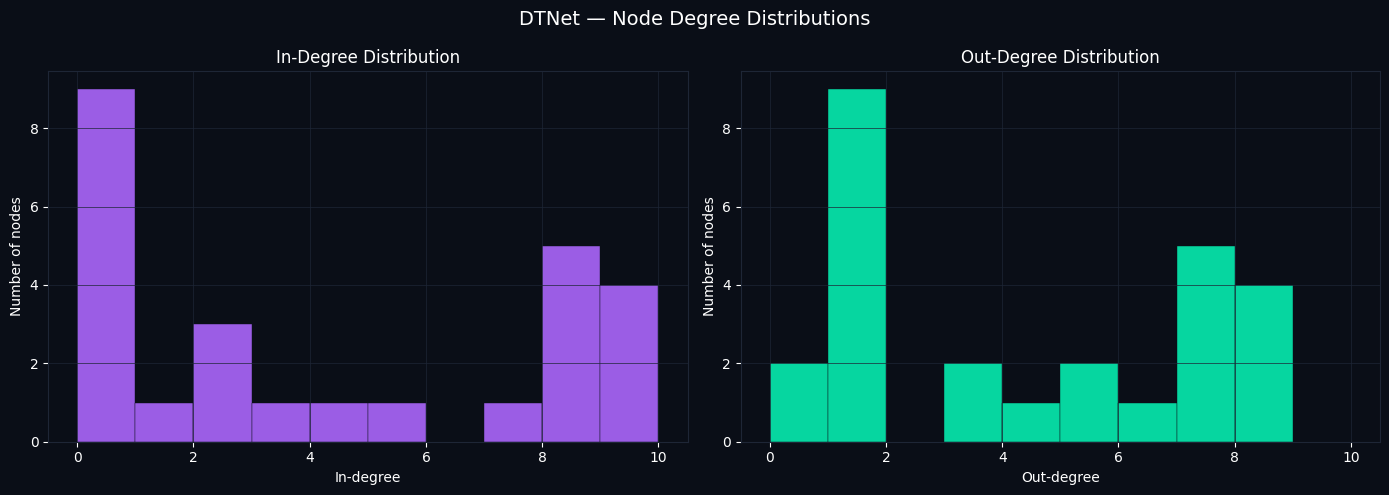

In [35]:
in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

print(f"In-degree  — min={min(in_degrees)}, max={max(in_degrees)}, "
      f"mean={sum(in_degrees)/len(in_degrees):.2f}")
print(f"Out-degree — min={min(out_degrees)}, max={max(out_degrees)}, "
      f"mean={sum(out_degrees)/len(out_degrees):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
apply_dark_theme(fig, axes)

max_deg = max(max(in_degrees), max(out_degrees))
bins = range(0, max_deg + 2)

axes[0].hist(in_degrees, bins=bins, color=LAYER_COLORS["logistics"],
             edgecolor=BG_COLOR, linewidth=0.3)
axes[0].set_title("In-Degree Distribution", fontsize=12)
axes[0].set_xlabel("In-degree")
axes[0].set_ylabel("Number of nodes")

axes[1].hist(out_degrees, bins=bins, color=LAYER_COLORS["plant"],
             edgecolor=BG_COLOR, linewidth=0.3)
axes[1].set_title("Out-Degree Distribution", fontsize=12)
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Number of nodes")

fig.suptitle("DTNet — Node Degree Distributions", color=TEXT_COLOR, fontsize=14)
plt.tight_layout()
out_path = RESULTS_DIR / "dtnet_degree_distribution.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
print(f"Saved → {out_path}")
plt.show()

Saved → c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\dtnet_degree_by_layer.png


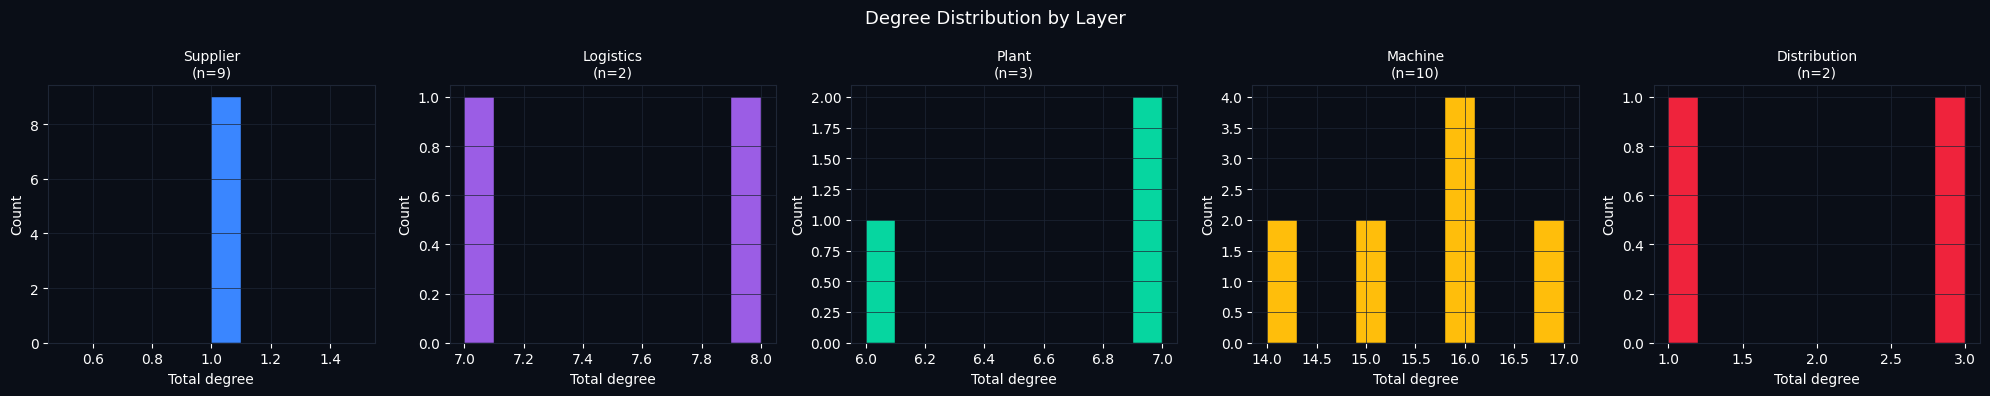

In [36]:
# ── degree distribution broken down per layer ─────────────────────────────
layer_order = ["supplier", "logistics", "plant", "machine", "distribution"]
layers_present = [l for l in layer_order
                  if any(G.nodes[n].get("layer") == l for n in G.nodes())]

fig, axes = plt.subplots(1, len(layers_present), figsize=(4 * len(layers_present), 4),
                          sharey=False)
if len(layers_present) == 1:
    axes = [axes]
apply_dark_theme(fig, axes)

for ax, layer in zip(axes, layers_present):
    layer_nodes = [n for n in G.nodes() if G.nodes[n].get("layer") == layer]
    degs = [G.degree(n) for n in layer_nodes]
    ax.hist(degs, bins=max(10, len(set(degs))),
            color=LAYER_COLORS[layer], edgecolor=BG_COLOR, linewidth=0.3)
    ax.set_title(f"{layer.capitalize()}\n(n={len(layer_nodes)})", fontsize=10)
    ax.set_xlabel("Total degree")
    ax.set_ylabel("Count")

fig.suptitle("Degree Distribution by Layer", color=TEXT_COLOR, fontsize=13)
plt.tight_layout()
out_path = RESULTS_DIR / "dtnet_degree_by_layer.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
print(f"Saved → {out_path}")
plt.show()

---
## 6. Cross-Plant Dependencies

In [37]:
# ── extract subgraph of shared_part_dependency edges ──────────────────────
spd_edges = [
    (u, v) for u, v, d in G.edges(data=True)
    if d.get("edge_type") == "shared_part_dependency"
]
spd_nodes = set()
for u, v in spd_edges:
    spd_nodes.add(u)
    spd_nodes.add(v)

print(f"shared_part_dependency edges : {len(spd_edges):,}")
print(f"Machines involved            : {len(spd_nodes):,}")

# Which plants do they belong to?
plant_membership: dict = {}
for node_id in spd_nodes:
    for plant_code, machines in em.plant_to_machines.items():
        if node_id in machines:
            plant_membership[node_id] = plant_code
            break

from collections import Counter
plant_counts = Counter(plant_membership.values())
print("\nMachines with cross-plant dependencies per plant:")
for plant, cnt in sorted(plant_counts.items()):
    print(f"  {plant:<20}: {cnt:>4} machines")

shared_part_dependency edges : 66
Machines involved            : 10

Machines with cross-plant dependencies per plant:
  CHN-02              :    3 machines
  DHR-03              :    3 machines
  PUN-01              :    4 machines


Saved → c:\Users\hamza\OneDrive\Documents\MASTER THESIS\DTNet\Prototype\results\dtnet_cross_plant_dependencies.png


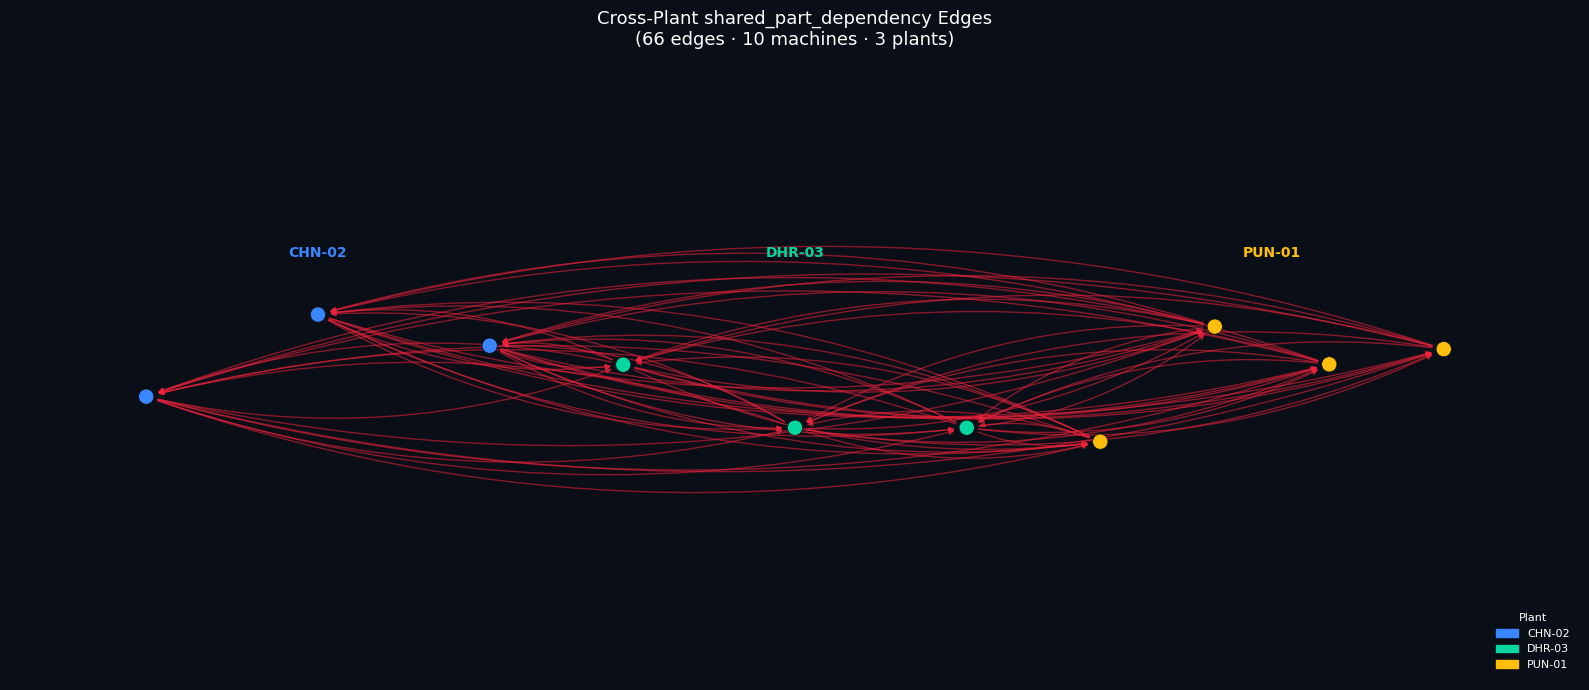

In [38]:
if not spd_edges:
    print("No shared_part_dependency edges in this graph — skipping plot.")
else:
    # Build subgraph for visualisation
    S = G.edge_subgraph(spd_edges).copy()

    # Position: cluster by plant, spread within each cluster
    plants_in_sub = sorted(set(plant_membership.get(n, "unknown") for n in S.nodes()))
    plant_x_base = {p: i * 2.5 for i, p in enumerate(plants_in_sub)}

    sub_pos = {}
    plant_node_lists: dict = {p: [] for p in plants_in_sub}
    for n in S.nodes():
        p = plant_membership.get(n, "unknown")
        plant_node_lists[p].append(n)

    for plant, pnodes in plant_node_lists.items():
        pnodes_sorted = sorted(pnodes)
        n_p = len(pnodes_sorted)
        for j, node_id in enumerate(pnodes_sorted):
            x = plant_x_base[plant] + (j / max(n_p - 1, 1)) * 1.8
            y = np.random.uniform(0.2, 0.8)   # slight vertical jitter
            sub_pos[node_id] = (x, y)

    np.random.seed(42)   # re-seed after jitter

    # Node colour by plant
    plant_palette = [
        "#3a86ff", "#06d6a0", "#ffbe0b", "#9b5de5", "#ef233c",
        "#fb5607", "#8ecae6", "#a8dadc",
    ]
    plant_color_map = {
        p: plant_palette[i % len(plant_palette)]
        for i, p in enumerate(plants_in_sub)
    }
    sub_node_colors = [
        plant_color_map.get(plant_membership.get(n, "unknown"), "white")
        for n in S.nodes()
    ]

    fig, ax = plt.subplots(figsize=(16, 7))
    apply_dark_theme(fig, ax)
    ax.grid(False)
    ax.set_axis_off()

    nx.draw_networkx_edges(
        S, sub_pos, ax=ax,
        edge_color=EDGE_COLORS["shared_part_dependency"],
        alpha=0.55, width=1.0,
        arrows=True, arrowsize=8,
        connectionstyle="arc3,rad=0.15",
        min_source_margin=5, min_target_margin=5,
    )
    nx.draw_networkx_nodes(
        S, sub_pos, ax=ax,
        node_color=sub_node_colors,
        node_size=120, linewidths=0.5, edgecolors=BG_COLOR,
    )

    # Plant cluster labels
    for plant, pnodes in plant_node_lists.items():
        xs = [sub_pos[n][0] for n in pnodes]
        ax.text(
            sum(xs) / len(xs), 1.0, plant,
            ha="center", va="bottom",
            color=plant_color_map[plant], fontsize=10, fontweight="bold",
        )

    # Legend
    plant_patches = [
        mpatches.Patch(color=plant_color_map[p], label=p)
        for p in plants_in_sub
    ]
    ax.legend(
        handles=plant_patches, title="Plant",
        title_fontsize=8, fontsize=8,
        loc="lower right", framealpha=0.15,
        labelcolor=TEXT_COLOR,
        facecolor=BG_COLOR, edgecolor=GRID_COLOR,
    )
    ax.get_legend().get_title().set_color(TEXT_COLOR)

    ax.set_title(
        f"Cross-Plant shared_part_dependency Edges\n"
        f"({len(spd_edges)} edges · {len(spd_nodes)} machines · "
        f"{len(plants_in_sub)} plants)",
        color=TEXT_COLOR, fontsize=13, pad=12,
    )

    plt.tight_layout()
    out_path = RESULTS_DIR / "dtnet_cross_plant_dependencies.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
    print(f"Saved → {out_path}")
    plt.show()

---
## Summary

| Item | Value |
|------|-------|
| Total nodes | _(run cells above)_ |
| Total edges | _(run cells above)_ |
| Supplier nodes | _(run cells above)_ |
| Logistics nodes | 2 (HUB_A, HUB_B) |
| Plant nodes | _(run cells above)_ |
| Machine nodes | _(run cells above)_ |
| Distribution nodes | 2 (DIST_MAIN, DIST_EXPORT) |
| Cross-plant dependency edges | _(run cells above)_ |
| Top critical node | _(run cells above)_ |

**Saved figures:**
- `results/dtnet_graph.png` — full layered graph
- `results/dtnet_critical_nodes.png` — top-5 critical nodes highlighted
- `results/dtnet_degree_distribution.png` — in/out-degree histograms
- `results/dtnet_degree_by_layer.png` — degree distribution per layer
- `results/dtnet_cross_plant_dependencies.png` — shared-part dependency subgraph

**Next:** `03_simulation_runs.ipynb` — cascading failure simulation.